# scSHM plot

In [1]:
library(tidyverse)
library(ggnewscale)
library(colorspace)

Warning message:
“package ‘tidyverse’ was built under R version 4.1.2”
── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.4.0      ✔ purrr   1.0.1 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.3.0      ✔ stringr 1.5.0 
✔ readr   2.1.3      ✔ forcats 0.5.2 
Warning message:
“package ‘ggplot2’ was built under R version 4.1.2”
Warning message:
“package ‘tibble’ was built under R version 4.1.2”
Warning message:
“package ‘readr’ was built under R version 4.1.2”
Warning message:
“package ‘purrr’ was built under R version 4.1.2”
Warning message:
“package ‘dplyr’ was built under R version 4.1.2”
Warning message:
“package ‘stringr’ was built under R version 4.1.2”
Warning message:
“package ‘forcats’ was built under R version 4.1.2”
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [2]:
# Constants
# nucleotide palette
c.nucl_palette_values = c("A"="#53EE53", "C"="#5353EE", "G"="#EE5353", "T"="#EEEE53","-"="grey")
#c.nucl_palette <- c("grey","#53EE53", "#5353EE", "#EE5353", "#EEEE53")
# AID motifs
c.aid_patterns <- list(
  wrCy = list(motif = "wrCy", pattern = "[AT][AG]C[CT]", context_lengths = c(2, 1)),
  rCg = list(motif = "rCg", pattern = "[AG]CG", context_lengths = c(1, 1))
)
# height of the upper part of the plot (events and cdr regions)
c.event_height <- 14

In [3]:
#' Generates a dataframe where each row contains a position and a nucleotide
#' for both po (Primordial sequence) and cons (Cell consensus)
generate_sequences_df <- function(reference) {
  ref_df <- data.frame(
    pos = 1:str_length(reference$sequence),
    cons = unlist(strsplit(reference$sequence, split = "")),
    po = unlist(strsplit(reference$po_sequence, split = ""))
  ) %>%
    gather(key = "type", value = "nucleotide", -pos) %>%
    mutate(type = factor(type, levels = c("po", "cons")))
  return(ref_df)
}

In [4]:
#' Finds AID hotspots in a sequence and creates a dataframe with the type and position
find_aid_hotspots <- function(dnaseq, patterns = c.aid_patterns) {
  aid_hotspots <- list()
  for (i in 1:nchar(dnaseq)) {
    for (p in patterns) {
      cl <- p[["context_lengths"]]
      subseq <- substr(dnaseq, max(0, i - cl[1]), min(i + cl[2], nchar(dnaseq)))
      if (grepl(p[["pattern"]], subseq)) {
        aid_hotspots <- c(aid_hotspots, list(c(position = i, motif = p[["motif"]])))
      }
    }
  }
  df <- as.data.frame(do.call(rbind, aid_hotspots)) %>%
    mutate(position = as.integer(position))
  return(df)
}

#' Extract the AID motif context lenghts from the list definition
get_context_lengths <- function(motifs, side = "left") {
  idx <- if (side == "left") 1 else 2
  return(as.integer(sapply(motifs, function(x) {
    c.aid_patterns[[x]][["context_lengths"]][[idx]]
  })))
}

In [5]:
# function to make the plot
make_plot <- function(events_df, references_df, selected_subject, selected_cell) {
  # filter the dataframes to get the info for the target cell
  cell_events <- events_df %>%
    filter(cell == selected_cell, subject == selected_subject)
  reference <- references %>%
    filter(cell == selected_cell)

  # dataframe of the events prepared for the plot
  cell_events_df <- cell_events %>%
    select(vgene_position_aligned, variation, umis) %>%
    separate_rows(variation, umis, sep = "-") %>%
    rename(nucleotide = variation, position = vgene_position_aligned) %>%
    mutate(umis = as.integer(umis)) %>%
    arrange(desc(nucleotide)) %>%
    group_by(position) %>%
    mutate(
      ratio = umis / sum(umis),
      mid_cs_ratio = cumsum(ratio) - ratio / 2 # for text positions
    ) %>%
    ungroup()

  # dataframe containing CDR regions
  cdr_df <- reference %>%
    select(contains("cdr")) %>%
    gather(key, value) %>%
    separate(key, c("cdr", "side"), sep = "_") %>%
    spread(side, value)

  # dataframe of the sequences (cons and po)
  sequences_df <- generate_sequences_df(reference) %>%
    mutate(ycoord = as.integer(type) - 2) 

  # dataframe of the AID hotspots found in the cell consensus
  aid_hotspots <- find_aid_hotspots(reference$sequence) %>%
    mutate(
      left = position - get_context_lengths(motif, "left"),
      right = position + get_context_lengths(motif, "right"),
      motif = as.factor(motif),
      ycoord = as.integer(motif) - max(as.integer(motif)) - 2,
    )

  # the plot
  p <- ggplot() +
    # cdr regions
    geom_rect(
      data = cdr_df,
      aes(
        xmin = start - 0.5,
        xmax = end + 0.5,
        ymin = 0,
        ymax = c.event_height
      ),
      fill = "#ffebd6"
    ) +
    ## SHM events
    # "vague" bar
    geom_col(
      data = cell_events_df,
      aes(
        x = position,
        y = ratio * c.event_height,
        fill = nucleotide
      ),
      width = 2
    ) +
    # use a lightened version of the scale for the "vague" bar
    scale_fill_manual(values = lighten(c.nucl_palette_values, amount = 0.6), guide = "none") + ##c.nucl_palette
    new_scale_fill() +
    # "sharp" bar
    geom_col(
      data = cell_events_df,
      aes(
        x = position,
        y = ratio * c.event_height,
        fill = nucleotide
      ),
      width = 1
    ) +
    # bar texts
    geom_text(
      data = cell_events_df,
      aes(
        x = position + 2,
        y = mid_cs_ratio * c.event_height,
        label = sprintf("%2d UMIs", umis),
        hjust = 0,
        vjust = 0.5
      ),
      size = 3
    ) +
    ## sequences
    geom_rect(
      data = sequences_df,
      aes(
        xmin = pos - 0.5,
        xmax = pos + 0.5,
        ymin = ycoord - 0.9, #0.9
        ymax = ycoord - 0,
        fill = nucleotide
      )
    ) +
    annotate("text", x = -1, y = c(-0.5, -1.5), label = c("cons", "po"), hjust = 1) +
    ## AID hotspots
    # context
    geom_rect(
      data = aid_hotspots,
      aes(
        xmin = left - 0.5,
        xmax = right + 0.5,
        ymin = ycoord - 0.9, #0.9
        ymax = ycoord - 0
      ),
      fill = "#e0e0e0"
    ) +
    # cytosine
    geom_rect(
      data = aid_hotspots,
      aes(
        xmin = position - 0.5,
        xmax = position + 0.5,
        ymin = ycoord - 0.9, #0.9
        ymax = ycoord - 0
      ),
      fill = "SteelBlue"
    ) +
    annotate("text", x = -5, y = c(-2.5, -3.5), label = names(c.aid_patterns), hjust = .8) +
    scale_fill_manual(values = c.nucl_palette_values) + #c.nucl_palette
    theme_void() +
    theme(
      legend.title = element_blank()
    )

  return(p)
}

In [6]:
fig_save <- function(plot, filename = "plot", formats = c("svg", "pdf", "png"), ...) {
  for (format in formats) {
    ggplot2::ggsave(plot = plot, filename = paste(filename, format, sep = "."), ...)
  }
}

In [23]:
df <- read_csv("output/df_summary_K123_v1.csv")

Rows: 139 Columns: 9
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (7): subject, cell, nucl_po, context_po, subregion, variation, umis
dbl (1): vgene_position_aligned
lgl (1): productive

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [48]:
df 

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
K1B_S10000-LC,TTAGGCAGTCGAACAG,10,C,TG.TG,FR1,C-T,10-9,TRUE
K1B_S10000-LC,CTAGCCTCAATCACAC,60,C,AT.TC,FR1,C-G,11-14,TRUE
K1B_S10000-LC,ACTTTCACATTGTGCA,65,G,CT.CA,FR1,A-G,5-8,TRUE
K1B_S10000-LC,CTAGCCTCAATCACAC,150,C,AT.TA,FR2,A-C,7-11,TRUE
K1B_S144-HC,CTCGAGGCAATGACCT,33,G,GT.GT,FR1,A-G,5-6,TRUE
K1B_S144-HC,GTCACAACAACGATCT,132,G,GG.CT,FR2,C-G,6-6,TRUE
K1B_S144-HC,GTCACAACAACGATCT,167,G,AA.TA,CDR2,C-T,6-5,TRUE
K1B_S144-LC,TTTCCTCCACTTAAGC,4,A,AC.TC,FR1,A-G,6-7,TRUE
K1B_S144-LC,ATCATGGGTGGTCTCG,4,A,AC.TC,FR1,A-T,12-23,TRUE


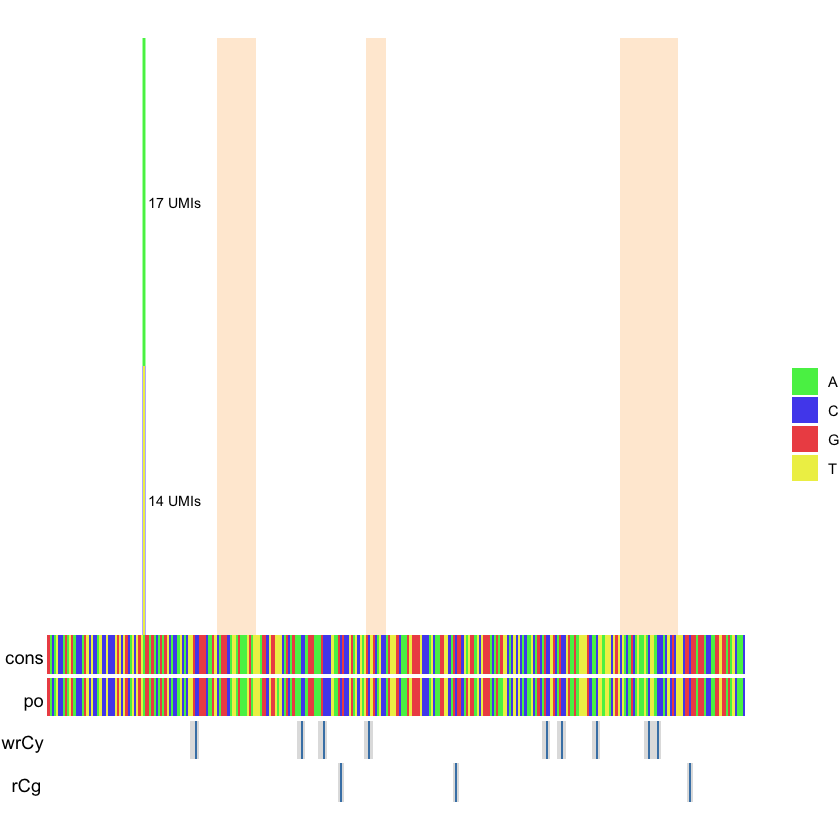

In [61]:
# load data
sub <- "K1B_S144-LC"
celula <- "CAAGTTGCAGCTGTGC"

df <- read_csv("output/df_summary_K123_v1.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, sub, celula)
dd

fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 25, height = 7, units = "cm", dpi = 320)

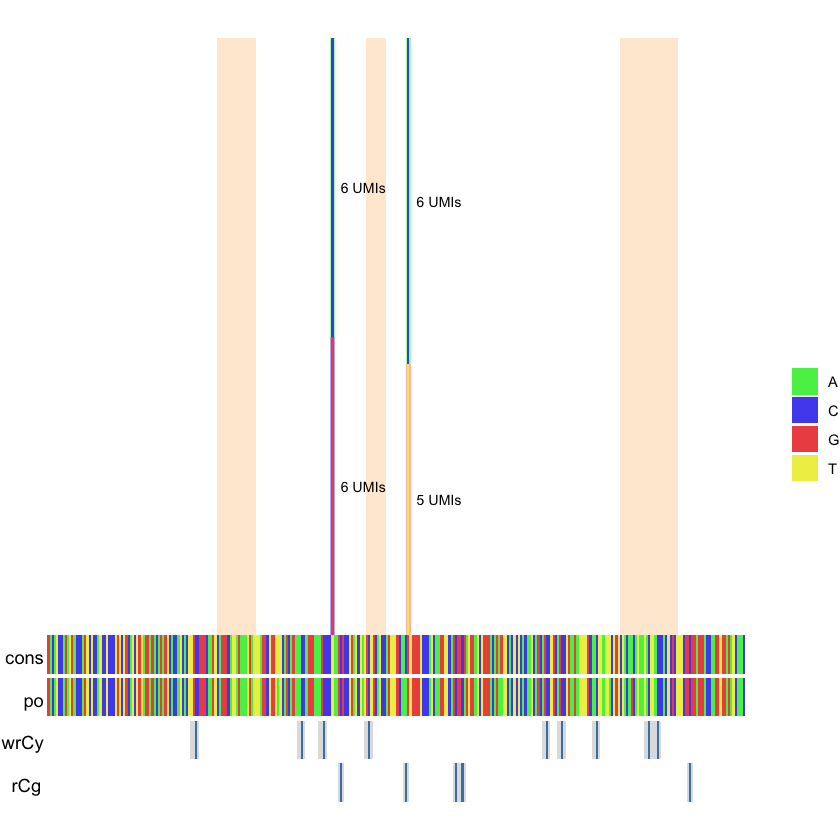

In [37]:
# load data
sub <- "K1B_S144-HC"
celula <- "GTCACAACAACGATCT"

df <- read_csv("output/df_summary_K123_v1.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, sub, celula)
dd

fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 25, height = 7, units = "cm", dpi = 320)

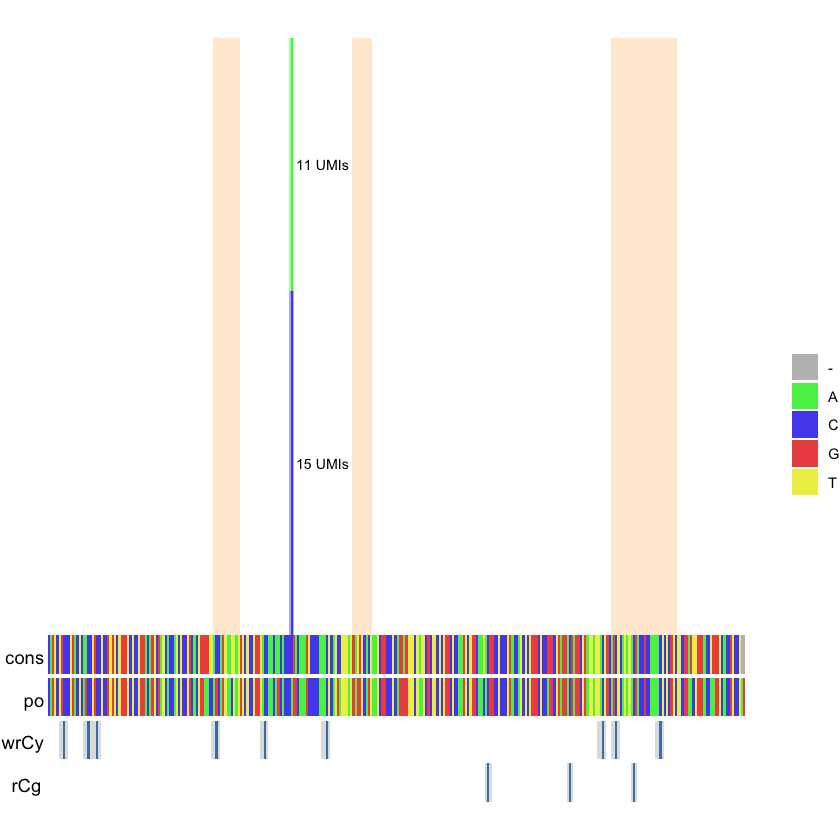

In [44]:
# load data
sub <- "K2B_S12500-HC"
celula <- "TACCTATAGCGATCCC"

df <- read_csv("output/df_summary_K123_v1.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, sub, celula)
dd

fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 25, height = 7, units = "cm", dpi = 320)

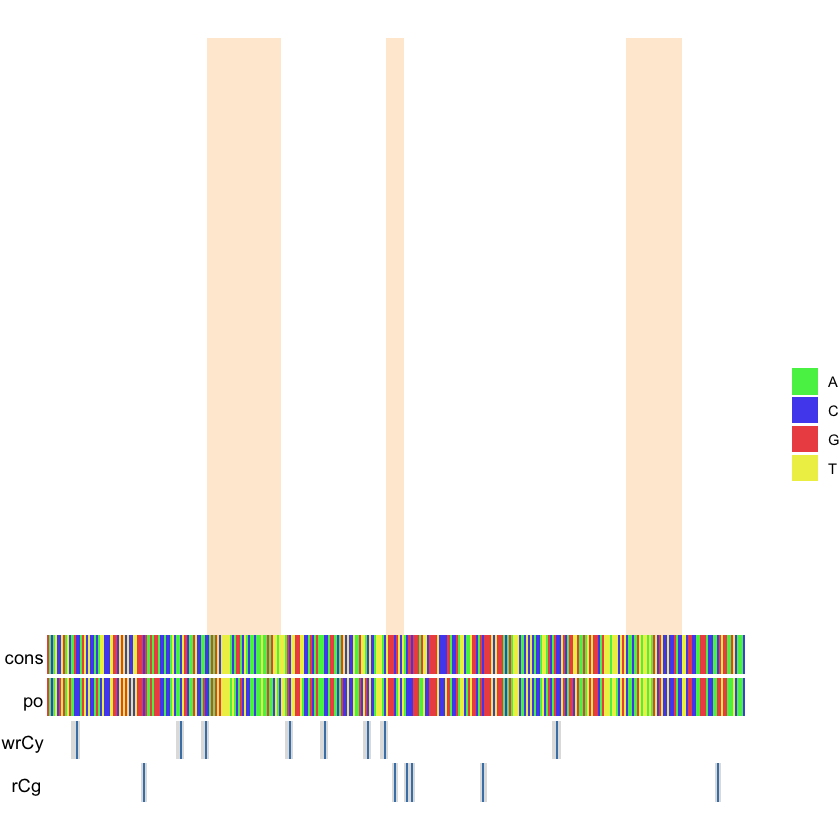

In [55]:
# load data
sub <- "K2B_S13530-LC"
celula <- "GATCGTATCCCATTTA"

df <- read_csv("output/df_summary_K123_v1.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, sub, celula)
dd

fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 17, height = 10, units = "cm", dpi = 320)

In [57]:
# load data
sub <- "K1B_S10000-LC"
celula <- "CTAGCCTCAATCACAC"

df <- read_csv("output/df_summary_K123_v1.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, sub, celula)
dd

fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 17, height = 10, units = "cm", dpi = 320)

ERROR: Error in 1:str_length(reference$sequence): argument of length 0


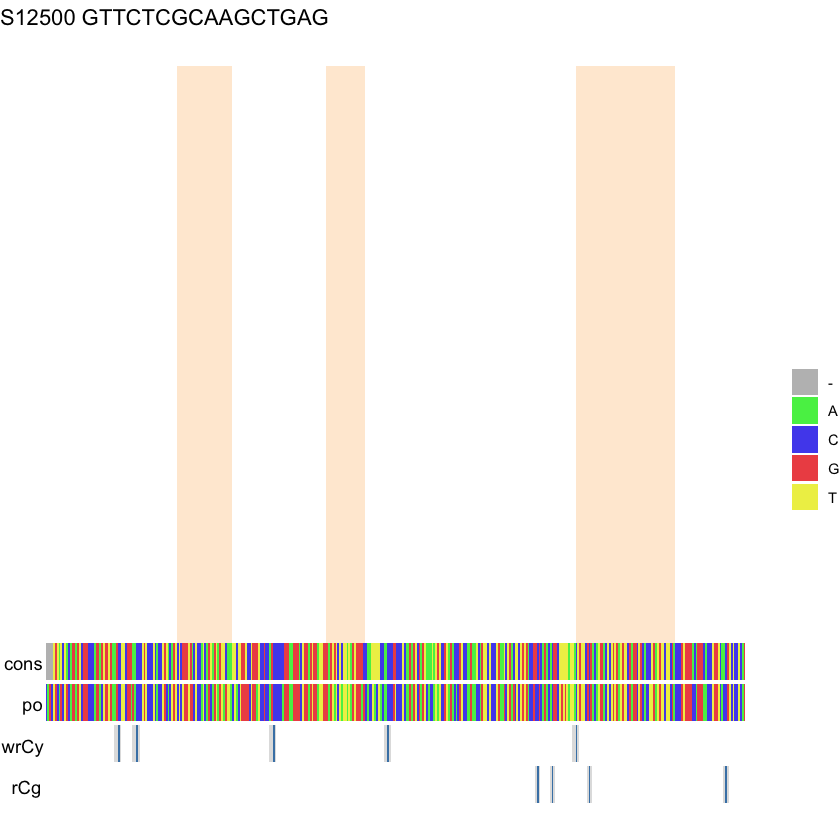

In [31]:
# cell 1 with intron

# load data
sub <- "K2B_S12500-HC"
caso <- "S12500"
celula <- "GTTCTCGCAAGCTGAG"

df <- read_csv("output/df_summary_K123_v1.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, "K2B_S12500-HC", "GTTCTCGCAAGCTGAG") +
     ggtitle(paste0(caso," ", celula))
dd

fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 17, height = 10, units = "cm", dpi = 320)

In [34]:
# cell 2 with intron

# load data
sub <- "K2B_S12500-HC"
caso <- "S12500"
celula <- "GAGCAGATCTAACTGG"

df <- read_csv("output/df_summary_K123_v1.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, "K2B_S12500-HC", "GAGCAGATCTAACTGG") +
     ggtitle(paste0(caso," ", celula))
dd

fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 17, height = 10, units = "cm", dpi = 320)

ERROR: [1m[33mError[39m in `spread()`:[22m
[1m[22m[33m![39m Each row of output must be identified by a unique combination of keys.
[36mℹ[39m Keys are shared for 12 rows
[36m•[39m 3, 4
[36m•[39m 7, 8
[36m•[39m 11, 12
[36m•[39m 1, 2
[36m•[39m 5, 6
[36m•[39m 9, 10


In [14]:
df %>% filter(cell == "GAGCAGATCTAACTGG")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
K2B_S12500-HC,GAGCAGATCTAACTGG,15,G,CA.GA,FR1,A-G,24-13,TRUE
K2B_S12500-HC,GAGCAGATCTAACTGG,70,G,CT.TC,FR1,A-G,16-10,TRUE
K2B_S12500-LC,GAGCAGATCTAACTGG,18,G,CA.CC,FR1,A-G,9-6,TRUE


In [15]:
# Cell 3 with intron

# load data
sub <- "K2B_S12500-HC"
caso <- "S12500"
celula <- "GAGCAGATCTAACTGG"

df <- read_csv("output/df_summary.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, "K2B_S12500-HC","GAGCAGATCTAACTGG") #+
#     ggtitle(paste0(caso," ", celula))
dd

#fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 17, height = 10, units = "cm", dpi = 320)

ERROR: [1m[33mError[39m in `spread()`:[22m
[1m[22m[33m![39m Each row of output must be identified by a unique combination of keys.
[36mℹ[39m Keys are shared for 12 rows
[36m•[39m 3, 4
[36m•[39m 7, 8
[36m•[39m 11, 12
[36m•[39m 1, 2
[36m•[39m 5, 6
[36m•[39m 9, 10


In [ ]:
# cell 4 with intron

# load data
sub <- "K2B_S12118-HC"
caso <- "S12118"
celula <- "CCACTACGTTAAGTAG"

df <- read_csv("output/df_summary.csv", show_col_types = FALSE)
references <- read_csv("input/references.csv", show_col_types = FALSE) %>%
  mutate(subject = paste0(experiment, "_", subject))

# plot one cell
dd <- make_plot(df, references, "K2B_S12118-HC", "CCACTACGTTAAGTAG") +
     ggtitle(paste0(caso," ", celula))
dd

fig_save(dd, filename = paste0("figs/FL/scSHM_",sub,"_", celula), formats = c("pdf", "png"), width = 17, height = 10, units = "cm", dpi = 320)